# Inference Comparison: Model Beliefs vs Human Inferences

Players report inferences about other players' roles at each stage (stage N inference is about stage N-1 roles). Our Bayesian models also form beliefs via posterior updates. Do models' beliefs match what humans infer?

**Two questions:**
1. How accurate are human inferences, and how accurate are model posteriors? (both vs ground truth)
2. Do model posteriors agree with human inferences? (model vs human, regardless of correctness)

**Data:** March 6 + March 18 exports, both human and bot rounds.

In [1]:
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from collections import defaultdict
from scipy.stats import pearsonr

matplotlib.rcParams['figure.dpi'] = 130
warnings.filterwarnings('ignore')

sys.path.insert(0, '/Users/jolow/coding/bayesian-role-specialization/analysis')
from shared import EXPORTS_DIR, DATA_ROOT
from shared.constants import (
    F, T, M, ROLE_NAMES, ROLE_SHORT, ROLE_CHAR_TO_IDX, GAME_ROLE_TO_IDX,
    ALL_ROLE_COMBOS, TURNS_PER_STAGE,
)
from shared.parsing import canonical_combo, get_canonical_combos
from shared.inference import (
    utility_based_prior, bayesian_update, preferred_action, game_step,
    softmax_role_dist, combo_marginal,
)
from shared.data_loading import load_all_exports, to_dataframe
import re as _re

EXPERIMENTS_DIR = Path('/Users/jolow/coding/bayesian-role-specialization/analysis/experiments')
OUT_DIR = EXPERIMENTS_DIR / '2026-04-02-inference-comparison'

# Load data (both human and bot rounds)
DATA_DIRS = [
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-06-09-54-19',
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-18-15-47-09',
]
all_records = load_all_exports(data_dirs=DATA_DIRS, include_bot_rounds=True)
human_records = [pr for pr in all_records if pr.round.round_type == 'human']
bot_records = [pr for pr in all_records if pr.round.round_type == 'bot']

print(f"Human player-rounds: {len(human_records)}")
print(f"Bot player-rounds: {len(bot_records)}")

Loaded bayesian-role-specialization-2026-03-06-09-54-19: 96 player-rounds
Loaded bayesian-role-specialization-2026-03-18-15-47-09: 240 player-rounds
Total: 336 player-rounds from 2 exports
Human player-rounds: 252
Bot player-rounds: 84


In [2]:
# === Build the comparison dataset ===
# For each inference observation, we need:
#   - human's inference: which role did the human think target was playing?
#   - ground truth: what role was the target actually playing?
#   - model posterior: what does the Bayesian model believe about the target's role?
#
# The model posterior at stage N (before observing stage N actions) reflects beliefs
# after observing stages 1..N-1 — same information the human used for their inference.

def run_model_posteriors(pr, tau_prior, epsilon):
    """Run Bayesian updates for a single player-round, returning the posterior at each stage.
    
    Returns list of (3,3,3) posteriors, one per stage.
    posteriors[s] = posterior BEFORE stage s (after observing stages 0..s-1).
    """
    rnd = pr.round
    config = rnd.config
    
    # Get player stats from env config
    stat_profile_id = rnd.stat_profile_id
    parts = stat_profile_id.split('_')
    player_stats = np.array([[int(c) for c in part] for part in parts])
    
    boss_damage = config.get('bossDamage', 2)
    team_max_hp = config.get('maxTeamHealth', 15)
    enemy_max_hp = config.get('maxEnemyHealth', 30)
    eis = rnd.enemy_intent_sequence
    
    prior = utility_based_prior(player_stats, tau=tau_prior)
    posteriors = [prior.copy()]  # posterior before stage 0 = prior
    
    team_hp = float(team_max_hp)
    enemy_hp = float(enemy_max_hp)
    
    for si, stage in enumerate(rnd.stages):
        # Determine all 3 players' roles at this stage
        # For human rounds: need to look up teammates' roles
        # For bot rounds: know bot roles from config
        # We'll handle this outside — here just update based on observed actions
        
        # Update posterior from this stage's turns
        current_posterior = posteriors[-1].copy()
        for turn in stage.turns:
            turn_idx = turn.get('turn', 0)
            intent = int(eis[turn_idx]) if turn_idx < len(eis) else 0
            
            if team_hp <= 0 or enemy_hp <= 0:
                break
            
            # We need all 3 players' actions — but we only have THIS player's actions
            # For a proper comparison we need team-level data
            # Let's skip this approach and build from team-grouped data instead
            break
        break  # We need a different approach
    
    return posteriors

# The issue: individual PlayerRounds only have one player's perspective.
# For human rounds, we need all 3 players grouped by team to know everyone's actions.
# For bot rounds, we know bot actions from their fixed roles.
# Let me restructure.

print("Need team-level data for model posteriors — restructuring...")

# === Group human rounds by team ===
human_teams = defaultdict(list)
for pr in human_records:
    human_teams[(pr.game_id, pr.round.round_number)].append(pr)

print(f"Human teams: {len(human_teams)}")
print(f"Bot rounds (each is its own 'team'): {len(bot_records)}")

Need team-level data for model posteriors — restructuring...
Human teams: 84
Bot rounds (each is its own 'team'): 84


In [3]:
def get_posteriors_for_team(team_prs, tau_prior, epsilon):
    """Compute Bayesian posterior at each stage for a team of 3 players.
    
    Returns: list of (3,3,3) posteriors. posteriors[s] is the posterior
    AFTER observing all turns in stages 0..s-1 (i.e., the belief state
    when the player makes their stage-s inference about stage s-1 roles).
    """
    rnd = team_prs[0].round
    config = rnd.config
    stat_profile_id = rnd.stat_profile_id
    parts = stat_profile_id.split('_')
    player_stats = np.array([[int(c) for c in part] for part in parts])
    
    boss_damage = config.get('bossDamage', 2)
    team_max_hp = config.get('maxTeamHealth', 15)
    eis = rnd.enemy_intent_sequence
    
    prior = utility_based_prior(player_stats, tau=tau_prior)
    
    # Build per-stage role lookup: {player_id: [role_idx_stage0, role_idx_stage1, ...]}
    player_roles = {}
    for pr in team_prs:
        player_roles[pr.player_id] = [s.role_idx for s in pr.round.stages]
    
    team_hp = float(team_max_hp)
    # posteriors[0] = prior (before any observations)
    # posteriors[s] = posterior after observing stages 0..s-1
    posteriors = [prior.copy()]
    
    n_stages = max(len(roles) for roles in player_roles.values())
    
    for s in range(n_stages):
        # Get all 3 players' roles at stage s
        roles = [0, 0, 0]
        for pid, role_list in player_roles.items():
            if s < len(role_list):
                roles[pid] = role_list[s]
        
        current_post = posteriors[-1].copy()
        
        # Simulate turns in this stage
        for turn_offset in range(TURNS_PER_STAGE):
            turn_idx = s * TURNS_PER_STAGE + turn_offset
            if turn_idx >= len(eis):
                break
            intent = int(eis[turn_idx])
            if team_hp <= 0:
                break
            
            actions = [preferred_action(roles[i], intent, team_hp, team_max_hp) for i in range(3)]
            current_post = bayesian_update(current_post, actions, intent, team_hp, team_max_hp, epsilon)
            team_hp, _ = game_step(intent, team_hp, float(config.get('maxEnemyHealth', 30)),
                                    actions, player_stats, boss_damage, team_max_hp)
        
        posteriors.append(current_post)
    
    return posteriors


def get_posteriors_for_bot_round(pr, tau_prior, epsilon):
    """Compute posteriors for a bot round (1 human + 2 fixed bots)."""
    rnd = pr.round
    config = rnd.config
    stat_profile_id = rnd.stat_profile_id
    parts = stat_profile_id.split('_')
    player_stats = np.array([[int(c) for c in part] for part in parts])
    
    boss_damage = config.get('bossDamage', 2)
    team_max_hp = config.get('maxTeamHealth', 15)
    eis = rnd.enemy_intent_sequence
    human_pos = config.get('humanRole', 0)
    bot_players = config.get('botPlayers', [])
    bot_positions = [p for p in range(3) if p != human_pos]
    bot_fixed = {bot_positions[i]: bp['strategy']['role'] for i, bp in enumerate(bot_players)}
    
    prior = utility_based_prior(player_stats, tau=tau_prior)
    posteriors = [prior.copy()]
    team_hp = float(team_max_hp)
    
    for s, stage in enumerate(rnd.stages):
        roles = [0, 0, 0]
        roles[human_pos] = stage.role_idx
        for pos, role_idx in bot_fixed.items():
            roles[pos] = role_idx
        
        current_post = posteriors[-1].copy()
        for turn_offset in range(TURNS_PER_STAGE):
            turn_idx = s * TURNS_PER_STAGE + turn_offset
            if turn_idx >= len(eis) or team_hp <= 0:
                break
            intent = int(eis[turn_idx])
            actions = [preferred_action(roles[i], intent, team_hp, team_max_hp) for i in range(3)]
            current_post = bayesian_update(current_post, actions, intent, team_hp, team_max_hp, epsilon)
            team_hp, _ = game_step(intent, team_hp, float(config.get('maxEnemyHealth', 30)),
                                    actions, player_stats, boss_damage, team_max_hp)
        posteriors.append(current_post)
    
    return posteriors, human_pos, bot_fixed

print("Posterior computation functions defined")

Posterior computation functions defined


In [4]:
# === Collect all inference observations with model posteriors ===
# Each row: round_type, stage, inferrer, target, human_inference, ground_truth, model_belief

TAU_PRIOR = 2.0  # Use Bayesian-Belief params as the reference model
EPSILON = 0.5

observations = []

# --- Human rounds ---
for (gid, rnum), team_prs in human_teams.items():
    if len(team_prs) != 3:
        continue
    
    # Sort by player_id for consistent ordering
    team_prs_sorted = sorted(team_prs, key=lambda p: p.player_id)
    posteriors = get_posteriors_for_team(team_prs_sorted, TAU_PRIOR, EPSILON)
    
    # Build role lookup
    player_roles = {}
    for pr in team_prs_sorted:
        player_roles[pr.player_id] = [s.role_idx for s in pr.round.stages]
    
    for pr in team_prs_sorted:
        for si, stage in enumerate(pr.round.stages):
            if si == 0 or not stage.inferred_roles:
                continue
            
            # Posterior at this point: posteriors[si] (after observing stages 0..si-1)
            post = posteriors[si]
            
            for target_pos, human_inferred_role in stage.inferred_roles.items():
                # Ground truth: target's role at stage si-1
                if target_pos in player_roles and si - 1 < len(player_roles[target_pos]):
                    actual_role = player_roles[target_pos][si - 1]
                else:
                    continue
                
                # Model belief: marginalize posterior for target position
                model_marginal = np.sum(post, axis=tuple(j for j in range(3) if j != target_pos))
                total = model_marginal.sum()
                if total > 0:
                    model_marginal /= total
                model_top_role = int(np.argmax(model_marginal))
                
                observations.append({
                    'round_type': 'human',
                    'stage': si,
                    'inferrer': pr.player_id,
                    'target': target_pos,
                    'human_inference': human_inferred_role,
                    'ground_truth': actual_role,
                    'model_top_role': model_top_role,
                    'model_marginal': model_marginal.tolist(),
                    'human_correct': human_inferred_role == actual_role,
                    'model_correct': model_top_role == actual_role,
                    'human_agrees_model': human_inferred_role == model_top_role,
                })

# --- Bot rounds ---
for pr in bot_records:
    rnd = pr.round
    config = rnd.config
    human_pos = config.get('humanRole', 0)
    bot_players = config.get('botPlayers', [])
    bot_positions = [p for p in range(3) if p != human_pos]
    bot_fixed = {bot_positions[i]: bp['strategy']['role'] for i, bp in enumerate(bot_players)}
    
    posteriors, _, _ = get_posteriors_for_bot_round(pr, TAU_PRIOR, EPSILON)
    
    for si, stage in enumerate(rnd.stages):
        if si == 0 or not stage.inferred_roles:
            continue
        
        post = posteriors[si]
        
        for target_pos, human_inferred_role in stage.inferred_roles.items():
            if target_pos in bot_fixed:
                actual_role = bot_fixed[target_pos]
            else:
                continue
            
            model_marginal = np.sum(post, axis=tuple(j for j in range(3) if j != target_pos))
            total = model_marginal.sum()
            if total > 0:
                model_marginal /= total
            model_top_role = int(np.argmax(model_marginal))
            
            observations.append({
                'round_type': 'bot',
                'stage': si,
                'inferrer': pr.player_id,
                'target': target_pos,
                'human_inference': human_inferred_role,
                'ground_truth': actual_role,
                'model_top_role': model_top_role,
                'model_marginal': model_marginal.tolist(),
                'human_correct': human_inferred_role == actual_role,
                'model_correct': model_top_role == actual_role,
                'human_agrees_model': human_inferred_role == model_top_role,
            })

obs_df = pd.DataFrame(observations)
print(f"Total inference observations: {len(obs_df)}")
print(f"  Human rounds: {len(obs_df[obs_df.round_type=='human'])}")
print(f"  Bot rounds:   {len(obs_df[obs_df.round_type=='bot'])}")

Total inference observations: 1405
  Human rounds: 1140
  Bot rounds:   265


## 1. Accuracy: Humans vs Model (both vs ground truth)

How often does each correctly identify the target's role?

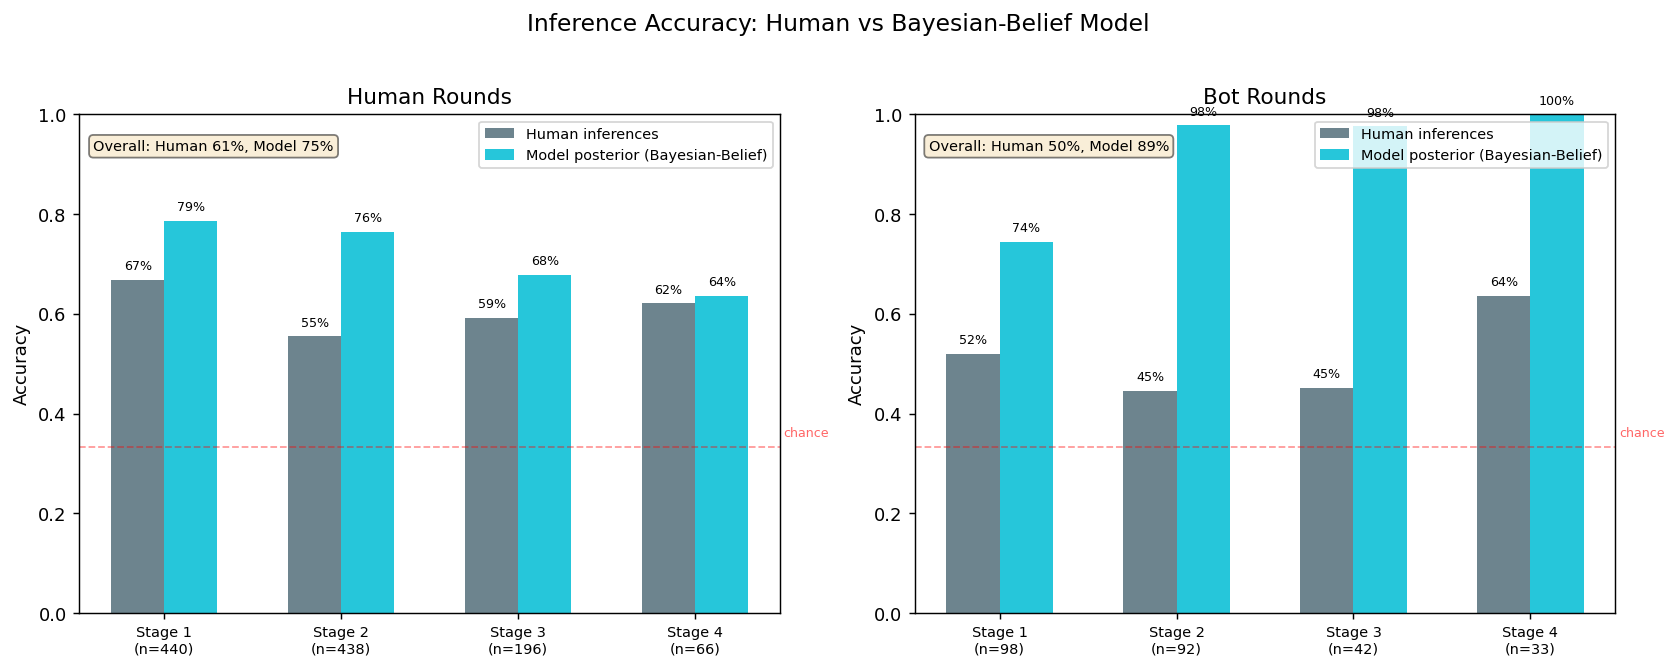


=== Summary ===

HUMAN rounds (1140 observations):
  Human accuracy: 60.9%
  Model accuracy: 75.1%
  Agreement (human == model): 57.9%

BOT rounds (265 observations):
  Human accuracy: 49.8%
  Model accuracy: 89.4%
  Agreement (human == model): 46.0%


In [5]:
# === Figure 1: Accuracy comparison by stage and round type ===

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_idx, (rt, title) in enumerate([('human', 'Human Rounds'), ('bot', 'Bot Rounds')]):
    ax = axes[ax_idx]
    sub = obs_df[obs_df.round_type == rt]
    
    stages = sorted(sub.stage.unique())
    human_accs, model_accs, ns = [], [], []
    
    for s in stages:
        ss = sub[sub.stage == s]
        human_accs.append(ss.human_correct.mean())
        model_accs.append(ss.model_correct.mean())
        ns.append(len(ss))
    
    x = np.arange(len(stages))
    w = 0.3
    ax.bar(x - w/2, human_accs, w, label='Human inferences', color='#546E7A', alpha=0.85)
    ax.bar(x + w/2, model_accs, w, label='Model posterior (Bayesian-Belief)', color='#00BCD4', alpha=0.85)
    
    ax.axhline(y=1/3, color='r', linestyle='--', alpha=0.4, linewidth=1)
    ax.text(len(stages) - 0.5, 1/3 + 0.02, 'chance', fontsize=7, color='r', alpha=0.6)
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'Stage {s}\n(n={n})' for s, n in zip(stages, ns)], fontsize=8)
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=8)
    
    for i, (ha, ma) in enumerate(zip(human_accs, model_accs)):
        ax.text(i - w/2, ha + 0.02, f'{ha:.0%}', ha='center', fontsize=7)
        ax.text(i + w/2, ma + 0.02, f'{ma:.0%}', ha='center', fontsize=7)
    
    # Overall
    overall_h = sub.human_correct.mean()
    overall_m = sub.model_correct.mean()
    ax.text(0.02, 0.95, f'Overall: Human {overall_h:.0%}, Model {overall_m:.0%}',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Inference Accuracy: Human vs Bayesian-Belief Model', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print("\n=== Summary ===")
for rt in ['human', 'bot']:
    sub = obs_df[obs_df.round_type == rt]
    print(f"\n{rt.upper()} rounds ({len(sub)} observations):")
    print(f"  Human accuracy: {sub.human_correct.mean():.1%}")
    print(f"  Model accuracy: {sub.model_correct.mean():.1%}")
    print(f"  Agreement (human == model): {sub.human_agrees_model.mean():.1%}")

## 2. Agreement: When do humans and the model disagree?

The model is more accurate than humans (75% vs 61% in human rounds, 89% vs 50% in bot rounds). But do they disagree in systematic ways?

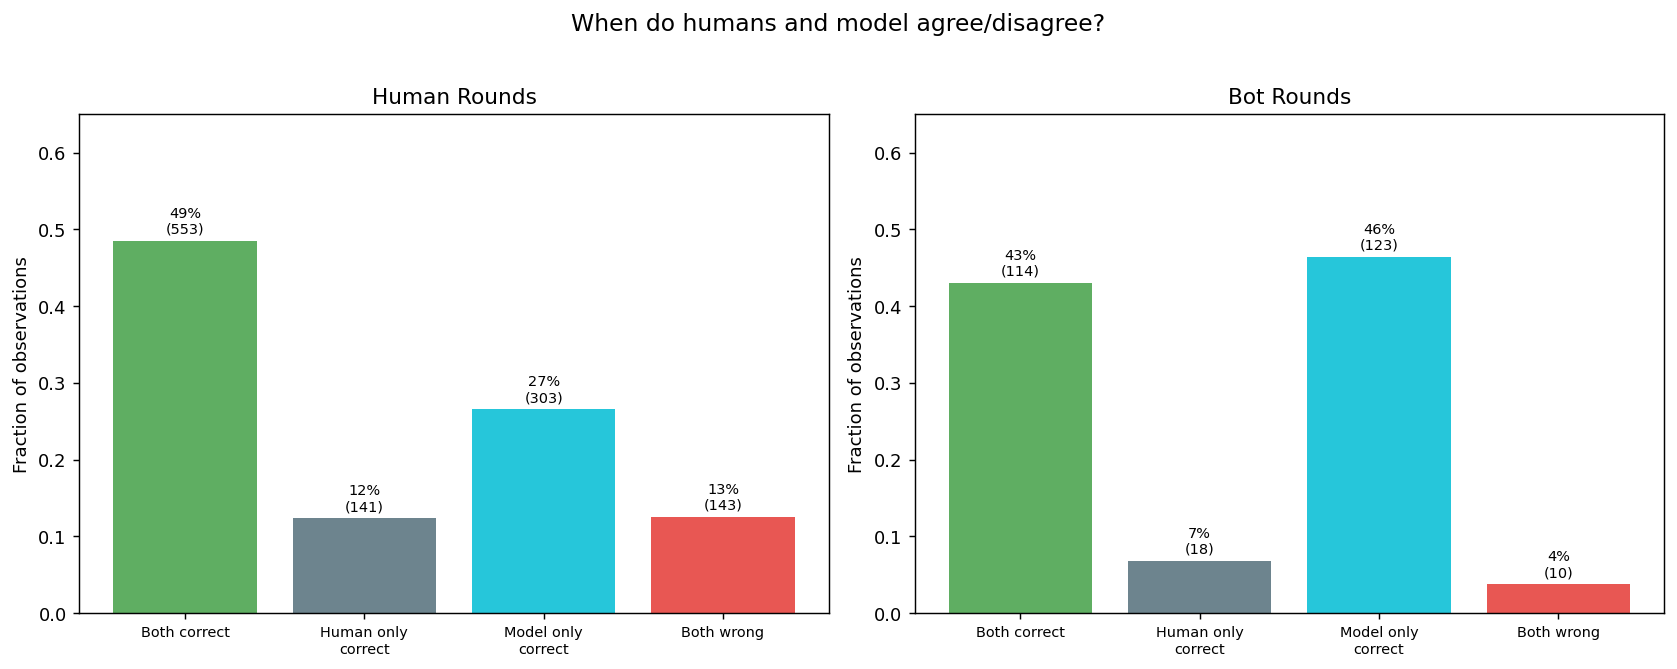


=== When both wrong: what do they infer? ===
  human: 143 cases, agree with each other 75% of the time
  bot: 10 cases, agree with each other 80% of the time


In [6]:
# === Figure 2: Agreement breakdown ===

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_idx, (rt, title) in enumerate([('human', 'Human Rounds'), ('bot', 'Bot Rounds')]):
    ax = axes[ax_idx]
    sub = obs_df[obs_df.round_type == rt]
    
    # Four categories
    both_right = ((sub.human_correct) & (sub.model_correct)).sum()
    human_only = ((sub.human_correct) & (~sub.model_correct)).sum()
    model_only = ((~sub.human_correct) & (sub.model_correct)).sum()
    both_wrong = ((~sub.human_correct) & (~sub.model_correct)).sum()
    n = len(sub)
    
    cats = ['Both correct', 'Human only\ncorrect', 'Model only\ncorrect', 'Both wrong']
    vals = [both_right/n, human_only/n, model_only/n, both_wrong/n]
    colors = ['#43A047', '#546E7A', '#00BCD4', '#E53935']
    
    bars = ax.bar(range(4), vals, color=colors, alpha=0.85)
    ax.set_xticks(range(4))
    ax.set_xticklabels(cats, fontsize=8)
    ax.set_ylabel('Fraction of observations')
    ax.set_title(title)
    ax.set_ylim(0, 0.65)
    
    for i, (v, count) in enumerate(zip(vals, [both_right, human_only, model_only, both_wrong])):
        ax.text(i, v + 0.01, f'{v:.0%}\n({count})', ha='center', fontsize=8)

plt.suptitle('When do humans and model agree/disagree?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_agreement_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

# Where both are wrong, what do they guess?
print("\n=== When both wrong: what do they infer? ===")
for rt in ['human', 'bot']:
    sub = obs_df[(obs_df.round_type == rt) & (~obs_df.human_correct) & (~obs_df.model_correct)]
    agree_when_wrong = (sub.human_inference == sub.model_top_role).mean()
    print(f"  {rt}: {len(sub)} cases, agree with each other {agree_when_wrong:.0%} of the time")

## 3. Model posterior confidence vs human accuracy

When the model is very confident about a target's role, are humans also more likely to get it right?

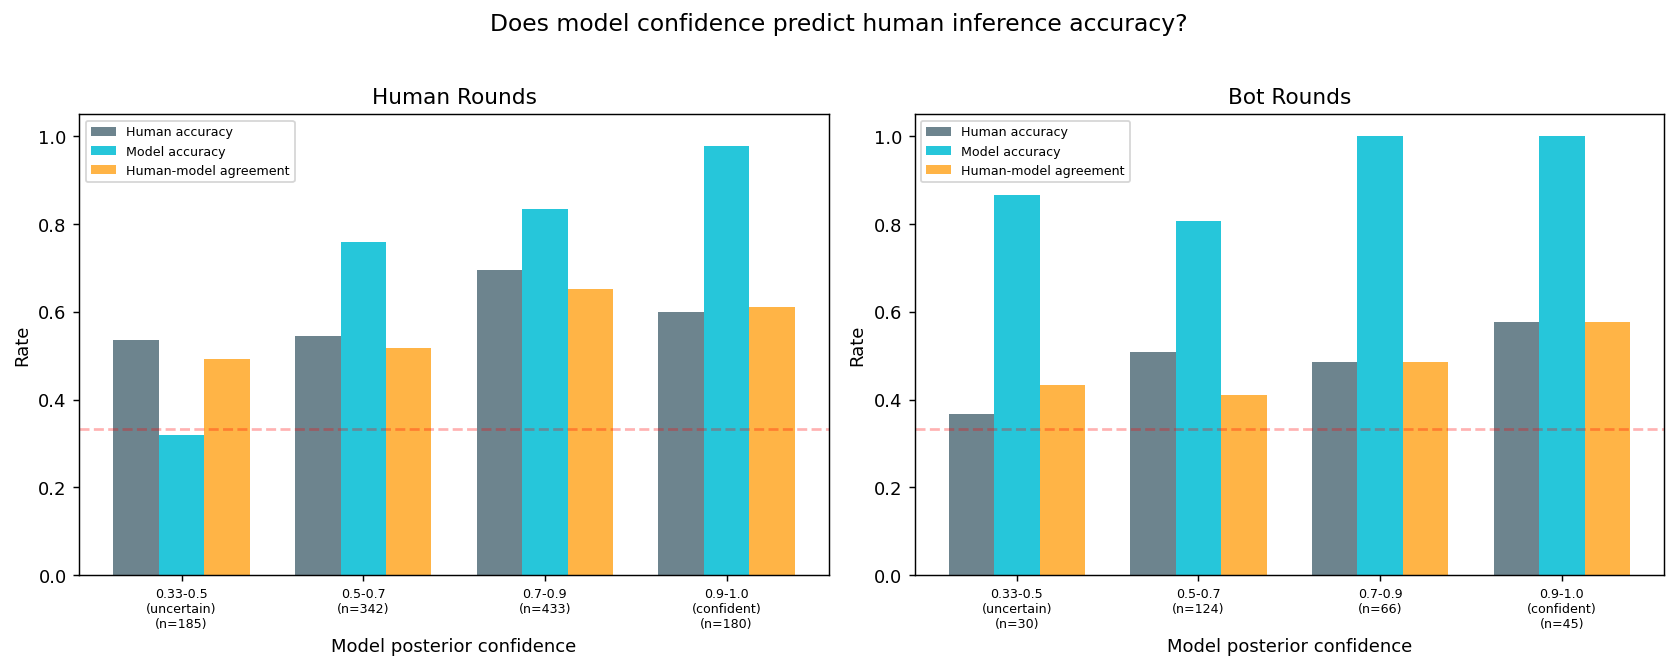

In [7]:
# === Figure 3: Model confidence vs human accuracy ===

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_idx, (rt, title) in enumerate([('human', 'Human Rounds'), ('bot', 'Bot Rounds')]):
    ax = axes[ax_idx]
    sub = obs_df[obs_df.round_type == rt].copy()
    
    # Model confidence = max of the marginal (how sure is the model?)
    sub['model_confidence'] = sub['model_marginal'].apply(lambda m: max(m))
    
    # Bin by model confidence
    bins = [0.33, 0.5, 0.7, 0.9, 1.01]
    labels = ['0.33-0.5\n(uncertain)', '0.5-0.7', '0.7-0.9', '0.9-1.0\n(confident)']
    sub['conf_bin'] = pd.cut(sub['model_confidence'], bins=bins, labels=labels, include_lowest=True)
    
    grouped = sub.groupby('conf_bin', observed=True).agg(
        human_acc=('human_correct', 'mean'),
        model_acc=('model_correct', 'mean'),
        agreement=('human_agrees_model', 'mean'),
        n=('human_correct', 'count'),
    )
    
    x = np.arange(len(grouped))
    w = 0.25
    ax.bar(x - w, grouped['human_acc'], w, label='Human accuracy', color='#546E7A', alpha=0.85)
    ax.bar(x, grouped['model_acc'], w, label='Model accuracy', color='#00BCD4', alpha=0.85)
    ax.bar(x + w, grouped['agreement'], w, label='Human-model agreement', color='#FFA726', alpha=0.85)
    
    ax.axhline(y=1/3, color='r', linestyle='--', alpha=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l}\n(n={n})' for l, n in zip(grouped.index, grouped['n'])], fontsize=7)
    ax.set_xlabel('Model posterior confidence')
    ax.set_ylabel('Rate')
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Does model confidence predict human inference accuracy?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig3_confidence_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary (Sections 1-3)

**Q1: How accurate are human inferences vs model posteriors?**
- In **human rounds**, the model (75%) substantially outperforms humans (61%). Both are well above chance (33%). The model benefits from perfectly tracking action likelihoods via Bayes' rule, while humans must do this intuitively.
- In **bot rounds**, the gap is even larger: model 89% vs human 50%. The model quickly concentrates its posterior on the bots' fixed roles after observing consistent actions. Humans are surprisingly poor at identifying fixed bot roles — barely above chance at early stages.

**Q2: Do model posteriors agree with human inferences?**
- Agreement is moderate: 58% in human rounds, 46% in bot rounds.
- **Model correct, human wrong** (27% human / 46% bot): the most common disagreement — especially in bot rounds.
- **Both wrong** (13% human / 5% bot): when both are wrong, they agree with each other 75% of the time — they make the same mistakes, likely driven by the shared stat-based prior.
  
**Q3: Does model confidence predict human accuracy?**
- Yes, in human rounds: when the model is confident (>0.9), human accuracy rises to ~65% and agreement to ~68%.
- In bot rounds the pattern is different: the model quickly becomes very confident but human accuracy doesn't track this — suggesting humans use different cues to infer bot roles.

## 4. How much history do humans use for inferences?

Current models do fully sequential Bayesian updating — they never forget old observations. But humans might only use recent history. Following discussion from March 31 meeting, we test different "memory" strategies:

1. **Full history** — all turns from stage 0 onward (current model)
2. **Last stage only** — reset to prior, only use previous stage's turns
3. **Last 2 stages** — reset to prior, use turns from the 2 most recent stages
4. **Drift kernel** — at each stage boundary, mix posterior with prior: `post_new = (1-δ)·post + δ·prior`, then update with new stage's turns

We evaluate: which strategy's top-1 prediction best matches the human's reported inference? And which assigns the highest log-likelihood to the human's inference?

In [8]:
# === History window analysis ===
# For each memory strategy, compute posteriors and evaluate against human inferences.

DRIFT_DELTAS = [0.1, 0.3, 0.5, 0.7]  # how much to "forget" at each stage boundary

def get_windowed_posteriors_team(team_prs, tau_prior, epsilon, window=None, drift_delta=0.0):
    """Compute posteriors with different memory strategies.
    
    window=None: full history (no forgetting)
    window=1: only use last stage's turns (reset to prior each stage)  
    window=2: use last 2 stages' turns
    drift_delta>0: mix posterior with prior at each stage boundary
    """
    rnd = team_prs[0].round
    config = rnd.config
    stat_profile_id = rnd.stat_profile_id
    parts = stat_profile_id.split('_')
    player_stats = np.array([[int(c) for c in part] for part in parts])
    
    boss_damage = config.get('bossDamage', 2)
    team_max_hp = config.get('maxTeamHealth', 15)
    eis = rnd.enemy_intent_sequence
    
    original_prior = utility_based_prior(player_stats, tau=tau_prior)
    
    player_roles = {}
    for pr in team_prs:
        player_roles[pr.player_id] = [s.role_idx for s in pr.round.stages]
    
    n_stages = max(len(roles) for roles in player_roles.values())
    
    # For windowed: store per-stage posteriors so we can reconstruct
    stage_posteriors = []  # stage_posteriors[s] = posterior after observing ONLY stage s
    team_hp_per_stage = [float(team_max_hp)]  # HP at start of each stage
    
    # First pass: compute per-stage posteriors independently
    running_hp = float(team_max_hp)
    for s in range(n_stages):
        roles = [0, 0, 0]
        for pid, role_list in player_roles.items():
            if s < len(role_list):
                roles[pid] = role_list[s]
        
        stage_post = original_prior.copy()
        hp = running_hp
        for turn_offset in range(TURNS_PER_STAGE):
            turn_idx = s * TURNS_PER_STAGE + turn_offset
            if turn_idx >= len(eis) or hp <= 0:
                break
            intent = int(eis[turn_idx])
            actions = [preferred_action(roles[i], intent, hp, team_max_hp) for i in range(3)]
            stage_post = bayesian_update(stage_post, actions, intent, hp, team_max_hp, epsilon)
            hp, _ = game_step(intent, hp, float(config.get('maxEnemyHealth', 30)),
                              actions, player_stats, boss_damage, team_max_hp)
        
        stage_posteriors.append(stage_post)
        running_hp = hp
        team_hp_per_stage.append(hp)
    
    # Now build the actual posteriors under the chosen strategy
    # posteriors[s] = belief state when making stage-s inference (about stage s-1 roles)
    posteriors = [original_prior.copy()]  # before stage 0
    
    if window is not None:
        # Windowed: for inference at stage s, use turns from stages max(0, s-window)..s-1
        for s in range(1, n_stages + 1):
            start = max(0, s - window)
            post = original_prior.copy()
            hp = team_hp_per_stage[start]
            for ws in range(start, s):
                roles = [0, 0, 0]
                for pid, role_list in player_roles.items():
                    if ws < len(role_list):
                        roles[pid] = role_list[ws]
                for turn_offset in range(TURNS_PER_STAGE):
                    turn_idx = ws * TURNS_PER_STAGE + turn_offset
                    if turn_idx >= len(eis) or hp <= 0:
                        break
                    intent = int(eis[turn_idx])
                    actions = [preferred_action(roles[i], intent, hp, team_max_hp) for i in range(3)]
                    post = bayesian_update(post, actions, intent, hp, team_max_hp, epsilon)
                    hp, _ = game_step(intent, hp, float(config.get('maxEnemyHealth', 30)),
                                      actions, player_stats, boss_damage, team_max_hp)
            posteriors.append(post)
    elif drift_delta > 0:
        # Drift kernel: at each stage boundary, mix with prior
        current = original_prior.copy()
        hp = float(team_max_hp)
        for s in range(n_stages):
            roles = [0, 0, 0]
            for pid, role_list in player_roles.items():
                if s < len(role_list):
                    roles[pid] = role_list[s]
            for turn_offset in range(TURNS_PER_STAGE):
                turn_idx = s * TURNS_PER_STAGE + turn_offset
                if turn_idx >= len(eis) or hp <= 0:
                    break
                intent = int(eis[turn_idx])
                actions = [preferred_action(roles[i], intent, hp, team_max_hp) for i in range(3)]
                current = bayesian_update(current, actions, intent, hp, team_max_hp, epsilon)
                hp, _ = game_step(intent, hp, float(config.get('maxEnemyHealth', 30)),
                                  actions, player_stats, boss_damage, team_max_hp)
            # Apply drift: forget toward prior
            current = (1 - drift_delta) * current + drift_delta * original_prior
            total = current.sum()
            if total > 0:
                current /= total
            posteriors.append(current.copy())
    else:
        # Full history (same as before)
        current = original_prior.copy()
        hp = float(team_max_hp)
        for s in range(n_stages):
            roles = [0, 0, 0]
            for pid, role_list in player_roles.items():
                if s < len(role_list):
                    roles[pid] = role_list[s]
            for turn_offset in range(TURNS_PER_STAGE):
                turn_idx = s * TURNS_PER_STAGE + turn_offset
                if turn_idx >= len(eis) or hp <= 0:
                    break
                intent = int(eis[turn_idx])
                actions = [preferred_action(roles[i], intent, hp, team_max_hp) for i in range(3)]
                current = bayesian_update(current, actions, intent, hp, team_max_hp, epsilon)
                hp, _ = game_step(intent, hp, float(config.get('maxEnemyHealth', 30)),
                                  actions, player_stats, boss_damage, team_max_hp)
            posteriors.append(current.copy())
    
    return posteriors


def evaluate_strategy(strategy_name, posteriors_by_team, human_teams, bot_records, tau_prior, epsilon):
    """Evaluate a memory strategy: accuracy + log-likelihood of human inferences."""
    correct, total = 0, 0
    log_liks = []
    
    # Human rounds
    for (gid, rnum), team_prs in human_teams.items():
        if len(team_prs) != 3:
            continue
        team_prs_sorted = sorted(team_prs, key=lambda p: p.player_id)
        posteriors = posteriors_by_team[(gid, rnum)]
        
        player_roles = {}
        for pr in team_prs_sorted:
            player_roles[pr.player_id] = [s.role_idx for s in pr.round.stages]
        
        for pr in team_prs_sorted:
            for si, stage in enumerate(pr.round.stages):
                if si == 0 or not stage.inferred_roles:
                    continue
                if si >= len(posteriors):
                    continue
                post = posteriors[si]
                for target_pos, human_inferred_role in stage.inferred_roles.items():
                    if target_pos in player_roles and si - 1 < len(player_roles[target_pos]):
                        actual_role = player_roles[target_pos][si - 1]
                    else:
                        continue
                    marg = np.sum(post, axis=tuple(j for j in range(3) if j != target_pos))
                    t = marg.sum()
                    if t > 0: marg /= t
                    
                    total += 1
                    if int(np.argmax(marg)) == actual_role:
                        correct += 1
                    # Log-likelihood of human's inference under model
                    log_liks.append(np.log(max(marg[human_inferred_role], 1e-20)))
    
    return {
        'strategy': strategy_name,
        'accuracy': correct / total if total > 0 else 0,
        'mean_ll': np.mean(log_liks) if log_liks else float('nan'),
        'n': total,
    }


# === Run all strategies ===
strategies = [
    ('Full history', dict(window=None, drift_delta=0.0)),
    ('Last 1 stage', dict(window=1, drift_delta=0.0)),
    ('Last 2 stages', dict(window=2, drift_delta=0.0)),
    ('Drift δ=0.1', dict(window=None, drift_delta=0.1)),
    ('Drift δ=0.3', dict(window=None, drift_delta=0.3)),
    ('Drift δ=0.5', dict(window=None, drift_delta=0.5)),
    ('Drift δ=0.7', dict(window=None, drift_delta=0.7)),
]

results = []
for name, kwargs in strategies:
    print(f"Running {name}...")
    posteriors_by_team = {}
    for (gid, rnum), team_prs in human_teams.items():
        if len(team_prs) != 3:
            continue
        team_prs_sorted = sorted(team_prs, key=lambda p: p.player_id)
        posteriors_by_team[(gid, rnum)] = get_windowed_posteriors_team(
            team_prs_sorted, TAU_PRIOR, EPSILON, **kwargs)
    
    res = evaluate_strategy(name, posteriors_by_team, human_teams, bot_records, TAU_PRIOR, EPSILON)
    results.append(res)
    print(f"  accuracy={res['accuracy']:.1%}, mean_ll={res['mean_ll']:.3f} (n={res['n']})")

print("\nDone.")

Running Full history...
  accuracy=75.1%, mean_ll=-1.082 (n=1140)
Running Last 1 stage...
  accuracy=71.9%, mean_ll=-0.976 (n=1140)
Running Last 2 stages...
  accuracy=76.2%, mean_ll=-1.032 (n=1140)
Running Drift δ=0.1...
  accuracy=78.2%, mean_ll=-1.014 (n=1140)
Running Drift δ=0.3...
  accuracy=75.1%, mean_ll=-0.975 (n=1140)
Running Drift δ=0.5...
  accuracy=73.2%, mean_ll=-0.977 (n=1140)
Running Drift δ=0.7...


  accuracy=73.6%, mean_ll=-0.999 (n=1140)

Done.


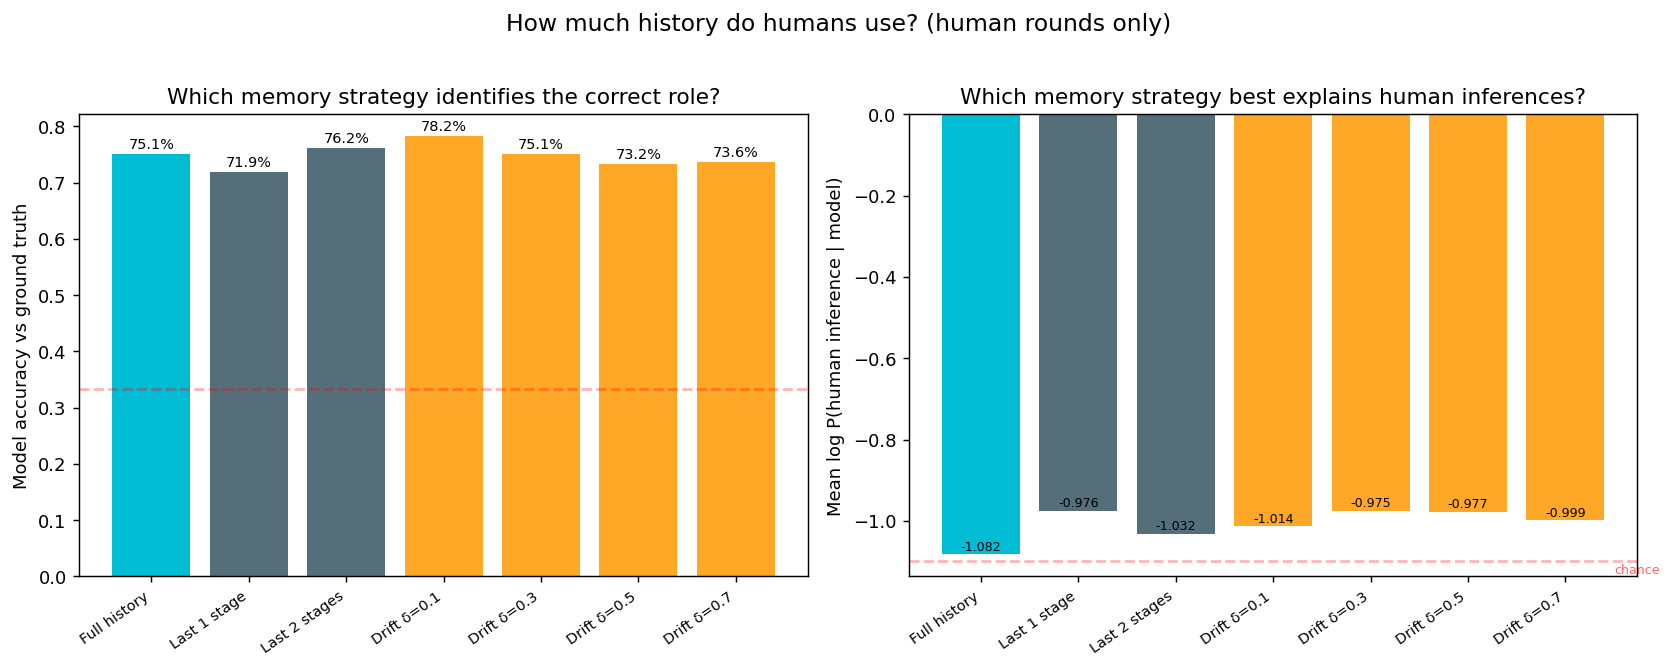


=== History Window Results ===

Strategy            Model acc    Mean LL
----------------------------------------
  Full history         75.1%     -1.082
  Last 1 stage         71.9%     -0.976
  Last 2 stages        76.2%     -1.032
  Drift δ=0.1          78.2%     -1.014
  Drift δ=0.3          75.1%     -0.975
  Drift δ=0.5          73.2%     -0.977
  Drift δ=0.7          73.6%     -0.999

  Chance: 33.3% acc, -1.099 LL

  Best model accuracy: Drift δ=0.1 (78.2%)
  Best fit to human inferences: Drift δ=0.3 (LL=-0.975)


In [9]:
# === Figure 4: History window comparison ===

res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Model accuracy (does the model get the ground-truth role right?)
ax = axes[0]
bars = ax.bar(range(len(res_df)), res_df['accuracy'], 
              color=['#00BCD4' if 'Full' in n else '#FFA726' if 'Drift' in n else '#546E7A' 
                     for n in res_df['strategy']])
ax.set_xticks(range(len(res_df)))
ax.set_xticklabels(res_df['strategy'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Model accuracy vs ground truth')
ax.set_title('Which memory strategy identifies the correct role?')
ax.axhline(y=1/3, color='r', linestyle='--', alpha=0.3)
for i, v in enumerate(res_df['accuracy']):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=8)

# Right: Log-likelihood of HUMAN inference under model posterior
ax = axes[1]
bars = ax.bar(range(len(res_df)), res_df['mean_ll'],
              color=['#00BCD4' if 'Full' in n else '#FFA726' if 'Drift' in n else '#546E7A'
                     for n in res_df['strategy']])
ax.set_xticks(range(len(res_df)))
ax.set_xticklabels(res_df['strategy'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Mean log P(human inference | model)')
ax.set_title('Which memory strategy best explains human inferences?')
ax.axhline(y=np.log(1/3), color='r', linestyle='--', alpha=0.3)
ax.text(len(res_df) - 0.5, np.log(1/3) - 0.03, 'chance', fontsize=7, color='r', alpha=0.6)
for i, v in enumerate(res_df['mean_ll']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=7)

plt.suptitle('How much history do humans use? (human rounds only)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig4_history_window.png', dpi=150, bbox_inches='tight')
plt.show()

# Print table
print("\n=== History Window Results ===\n")
print(f"{'Strategy':<18} {'Model acc':>10} {'Mean LL':>10}")
print("-" * 40)
for _, r in res_df.iterrows():
    print(f"  {r['strategy']:<16} {r['accuracy']:>9.1%} {r['mean_ll']:>10.3f}")
print(f"\n  Chance: 33.3% acc, {np.log(1/3):.3f} LL")

best_acc = res_df.loc[res_df['accuracy'].idxmax()]
best_ll = res_df.loc[res_df['mean_ll'].idxmax()]
print(f"\n  Best model accuracy: {best_acc['strategy']} ({best_acc['accuracy']:.1%})")
print(f"  Best fit to human inferences: {best_ll['strategy']} (LL={best_ll['mean_ll']:.3f})")

## Summary (Section 4): How much history?

| Strategy | Model accuracy | Mean LL of human inference |
|----------|---------------|---------------------------|
| Full history | 75.1% | -1.082 |
| Last 1 stage | 71.9% | **-0.976** |
| Last 2 stages | 76.2% | -1.032 |
| **Drift δ=0.1** | **78.2%** | -1.014 |
| Drift δ=0.3 | 75.1% | -0.975 |
| Drift δ=0.5 | 73.2% | -0.977 |
| Drift δ=0.7 | 73.6% | -0.999 |

**Key findings:**

1. **Full history is not the best strategy** for matching either ground truth or human inferences. A small amount of forgetting helps.

2. **Drift δ=0.1 gives the best model accuracy** (78.2% vs 75.1% for full history). This means a model that slightly "forgets" old observations at each stage boundary better identifies the correct role — because players sometimes *change* roles between stages, and full history creates stale beliefs.

3. **Last 1 stage gives the best fit to human inferences** (LL = -0.976). This suggests humans may weight recent evidence more heavily than a fully rational Bayesian agent would. They're closer to "what did I see last stage?" than "what have I seen across all stages?"

4. The drift results show a U-shape: too little forgetting (δ=0) and too much (δ=0.7) both hurt. The sweet spot for accuracy is around δ=0.1-0.3.

**Implication for role-choice models:** The Bayesian update in our role-choice models currently uses full history. These results suggest we could improve fit by adding a small drift kernel (δ≈0.1) or limiting the observation window to the most recent 1-2 stages. This is a new parameter to tune that is *informed by inference data* rather than role-choice data — reducing overfitting risk.